In [51]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [58]:
import torch
import numpy as np

a = torch.randn(1, 2, 4).numpy()
b = torch.randn(1, 3, 4).numpy()


c = np.concatenate([a, b], axis=0)



ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 1, the array at index 0 has size 2 and the array at index 1 has size 3

In [57]:
c.shape

(5, 4)

In [47]:
import torch
x = torch.randn(3, 4, 4)

In [50]:
x.mean(axis=(1,2))

tensor([ 0.1409,  0.2610, -0.1188])

In [33]:
import os
import rootutils

rootutils.setup_root(os.getcwd(), indicator=".project-root", pythonpath=True)

from torchvision import transforms
import torch
from src.data.components.graphs_datamodules import (
    IMCBaseDictTransform,
    PickleDataset,
    PatchAugmentations,
)
from src.data.imc_datamodule import add_channel
import src.data.components.graphs_datamodules as gd
from torchvision.datasets import MNIST
from torch.utils.data import ConcatDataset, Dataset, random_split
from pathlib import Path

In [34]:
from src.models.components.plot import restore_tensor
import matplotlib.pyplot as plt

base_transforms = IMCBaseDictTransform(center_crop_size=7, normalize=False)

aug_transforms_train = gd.PatchAugmentations(
    prob=1.0,
    size=15,
    patch_size=1,
    center_crop_size=7
)

aug_transforms_val = gd.PatchAugmentations(
    prob=1.0,
    size=15,
    patch_size=1,
    is_validation=True,
    center_crop_size=7
)

dual_transforms_train = gd.DualOutputTransform(base_transforms, aug_transforms_train)

dual_transforms_val = gd.DualOutputTransform(base_transforms, aug_transforms_val)

train_path = Path("/raid/tnocon/data") / "IMC" / "nsclc2_panel1_train.h5"
test_path = Path("/raid/tnocon/data") / "IMC" / "nsclc2_panel1_test.h5"

trainset = PickleDataset(train_path, transform=dual_transforms_train)
testset = PickleDataset(test_path, transform=dual_transforms_val)

train_ratio, val_ratio, test_ratio, leftover_ratio = [4968, 0, 0, 0]

size_trainset = len(trainset)
size_testset = len(testset)
data_train, _ = random_split(
    dataset=trainset,
    lengths=[train_ratio, size_trainset - train_ratio],
    generator=torch.Generator().manual_seed(42),
)

train_dataset = gd.GridGraphDataset(grid_size=15, dataset=data_train, channels=list(range(64)))

train_loader = gd.DenseGraphDataLoader(
    dataset=train_dataset,
    batch_size=8,
    num_workers=7,
    pin_memory=False,
    persistent_workers=7 > 0,
)

In [35]:
c = 0
for i, el in enumerate(train_loader):
    if i > c:
        break

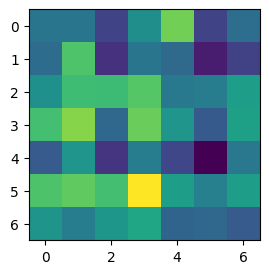

In [14]:
plt.figure(figsize=(3, 3))
plt.imshow(el.node_features[0][:, 0].view(7,7).numpy())
plt.show()

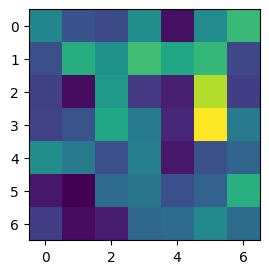

In [31]:
plt.figure(figsize=(3, 3))
plt.imshow(el.node_features[56][:, 0].view(7,7).numpy())
plt.show()

In [36]:
# Import necessary modules for PLGraphAE
import os
import rootutils

rootutils.setup_root(os.getcwd(), indicator=".project-root", pythonpath=True)

import torch
import lightning as L
from omegaconf import DictConfig, OmegaConf
from src.models.pigvae_auto_module import PLGraphAE
from src.models.components.modules import GraphAE
from src.models.components.schedulers import TemperatureScheduler, EntropyWeightScheduler
from src.models.components.model import Critic
from src.data.components.graphs_datamodules import DenseGraphBatch


In [37]:
import yaml

# Path to your YAML config file
config_path = "../configs/model/model.yaml"

# Load the YAML file
with open(config_path, "r") as f:
    model_config_raw = yaml.safe_load(f)

print("Converting configurations to DictConfig...")

# Register custom OmegaConf resolvers for multiply and divide
from omegaconf import OmegaConf

# Register multiply resolver if not already registered
if not OmegaConf.has_resolver("multiply"):
    OmegaConf.register_new_resolver("multiply", lambda x, y: x * y)

# Register divide resolver if not already registered
if not OmegaConf.has_resolver("divide"):
    OmegaConf.register_new_resolver("divide", lambda x, y: x // y)

# Wrap the config under 'model' and 'data' keys so interpolations work
# Also provide the missing data.hparams.num_aug_per_sample value
full_config = OmegaConf.create({
    "model": model_config_raw,
    "data": {
        "hparams": {
            "num_aug_per_sample": 8,
            "batch_size": 8
        }
    },
    "trainer": {
        "max_epochs": 500,  # Set these to match your training config
        "min_epochs": 1
    }
})

# Now resolve all interpolations
OmegaConf.resolve(full_config)

print("Creating GraphAE from resolved config...")
graph_ae = GraphAE(hparams=full_config.model.graph_ae.hparams)
print("GraphAE created successfully!")

print("Creating schedulers...")
temperature_scheduler = TemperatureScheduler(hparams=full_config.model.temperature_scheduler.hparams)
entropy_weight_scheduler = EntropyWeightScheduler(hparams=full_config.model.entropy_weight_scheduler.hparams)

print("Creating critic...")
critic = Critic(hparams=full_config.model.critic.hparams)

print("Creating optimizer (dummy for loading)...")
# Create a dummy optimizer for loading (it will be overridden by the checkpoint)
optimizer = torch.optim.Adam(graph_ae.parameters(), lr=0.0001)

print("Creating scheduler (dummy for loading)...")
# Create a dummy scheduler for loading
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=1)

print("All components created successfully!")


Converting configurations to DictConfig...
Creating GraphAE from resolved config...
GraphAE created successfully!
Creating schedulers...
Creating critic...
Creating optimizer (dummy for loading)...
Creating scheduler (dummy for loading)...
All components created successfully!


In [39]:
# Create the PLGraphAE model
print("Creating PLGraphAE model...")
# best_model = PLGraphAE(
#     graph_ae=graph_ae,
#     critic=critic,
#     temperature_scheduler=temperature_scheduler,
#     entropy_weight_scheduler=entropy_weight_scheduler,
#     optimizer=optimizer,
#     scheduler=scheduler,
#     compile=False
# )

last_model = PLGraphAE(
    graph_ae=graph_ae,
    critic=critic,
    temperature_scheduler=temperature_scheduler,
    entropy_weight_scheduler=entropy_weight_scheduler,
    optimizer=optimizer,
    scheduler=scheduler,
    compile=False
)

print("PLGraphAE model created successfully!")

Creating PLGraphAE model...


/home/tnocon/master_thesis/IMMUVIS-PIGVAE/.venv/lib/python3.12/site-packages/lightning/pytorch/utilities/parsing.py:209: Attribute 'critic' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['critic'])`.
/home/tnocon/master_thesis/IMMUVIS-PIGVAE/.venv/lib/python3.12/site-packages/lightning/pytorch/utilities/parsing.py:209: Attribute 'temperature_scheduler' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['temperature_scheduler'])`.
/home/tnocon/master_thesis/IMMUVIS-PIGVAE/.venv/lib/python3.12/site-packages/lightning/pytorch/utilities/parsing.py:209: Attribute 'entropy_weight_scheduler' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['entropy_weight_scheduler'])`.
/home/tnocon/master_thesis/IMMUVIS

PLGraphAE model created successfully!


In [38]:
DEVICE = 'cuda'

def load_model(ckpt_path: str, model: PLGraphAE):
    checkpoint = torch.load(ckpt_path, map_location='cuda', weights_only=False)
    model.load_state_dict(checkpoint['state_dict'])
    model.eval().to(DEVICE)
    return model, checkpoint

In [40]:
last_ckpt = "/raid/tnocon/logs/train/runs/2026-01-12_02-33-22/checkpoints/last.ckpt"

# best_model, best_checkpoint = load_model(best_ckpt, best_model)
last_model, last_checkpoint = load_model(last_ckpt, last_model)

In [41]:
def model_info(model: PLGraphAE, checkpoint: str):
    # Optional: Move model to GPU if available
    # device = 'cuda'
    # model = model.to(device)
    # print(f"Model moved to device: {device}")

    # Display model summary
    print("\nModel loaded successfully!")
    print(f"- Checkpoint epoch: {checkpoint.get('epoch', 'Unknown')}")
    print(f"- Global step: {checkpoint.get('global_step', 'Unknown')}")
    print(f"- Model device: {next(model.parameters()).device}")
    print(f"- Model parameters: {sum(p.numel() for p in model.parameters()):,}")
    print(f"- Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")


model_info(last_model, last_checkpoint)


Model loaded successfully!
- Checkpoint epoch: 186
- Global step: 423368
- Model device: cuda:0
- Model parameters: 18,551,433
- Trainable parameters: 18,551,305


In [43]:
c = 2
for i, el in enumerate(train_loader):
    if i > c:
        break

el = el.to('cuda')

last_model.eval()
with torch.no_grad():
    graph_emb, graph_pred, soft_probs, perm, mu, logvar = last_model(el, training=True, tau=0.1)

In [44]:
import src.models.components.metrics.recontructions as R
import src.models.components.plot as pL

idx_to_show = R.batch_augmented_indices(
            8, num_permutations=8, n_examples=4
        )
subset_predictions = graph_pred.node_features[idx_to_show, :, :]
subset_ground_truths = el.node_features[idx_to_show, :, :]

restore_subset_predictions = torch.stack(
            [img for img in subset_predictions], dim=0
        )
restore_subset_ground_truths = torch.stack(
            [img for img in subset_ground_truths],
            dim=0,
        )

ground_truth_imgs = restore_subset_ground_truths.detach().cpu()
pred_imgs = restore_subset_predictions.detach().cpu()
pred_min, pred_max = pred_imgs.min().item(), pred_imgs.max().item()
gt_min, gt_max = ground_truth_imgs.min().item(), ground_truth_imgs.max().item()

vmin = min(pred_min, gt_min)
vmax = max(pred_max, gt_max)


mse = R.mse_per_transform(ground_truth_imgs, pred_imgs, 4, 8)

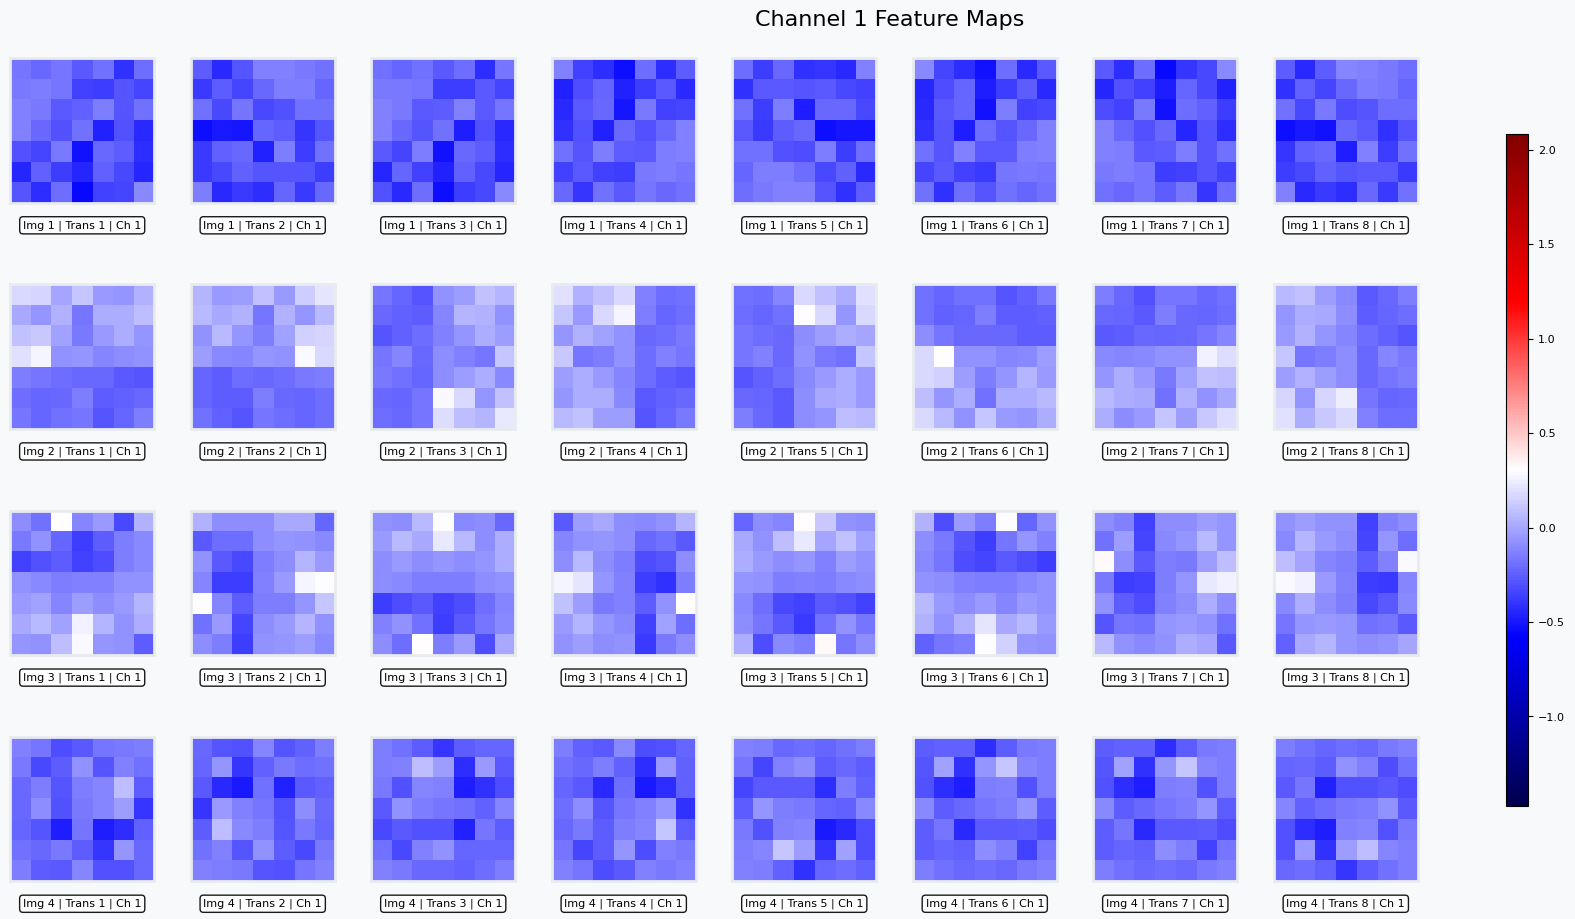

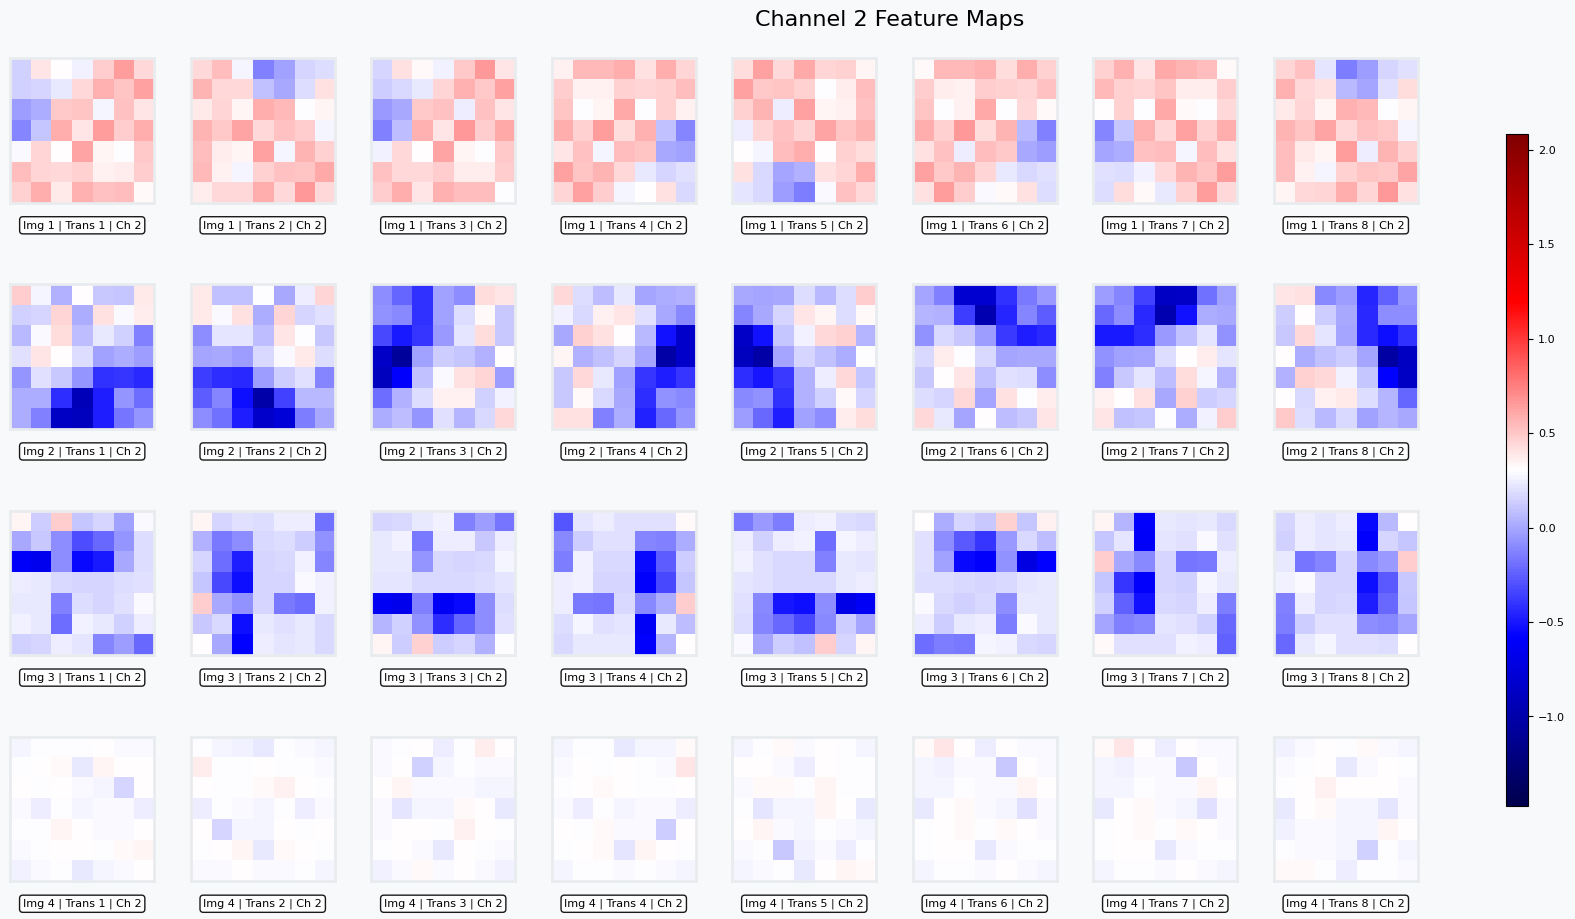

In [45]:
fig_prediction = pL.plot_feature_map(pred_imgs, 4, vmin=pred_min, vmax=pred_max)